# Hybrid Quantum Machine Learning Platform for Early Disease Detection
## Stage 04: Training 4-Qubit 2-Layer Variational Quantum Classifier (VQC) with PennyLane
**Target Application:** Lung Cancer Classification  
**Target Variable:** `LUNG_CANCER` (0 = NO, 1 = YES)  
**Input Dimensionality:** 4 Selected Clinical Predictors (`WHEEZING`, `YELLOW_FINGERS`, `AGE`, `SHORTNESS_OF_BREATH`)  
**Quantum Framework:** PennyLane (Noiseless Statevector Simulation on `default.qubit`)  

---

### Architecture Specification (4-Qubit 2-Layer VQC)
* **Data Encoding (Feature Vector $x$):**
  * $x_1 \to RY(x_1 \cdot \pi)$ on Wire 0 (`WHEEZING`)
  * $x_2 \to RY(x_2 \cdot \pi)$ on Wire 1 (`YELLOW_FINGERS`)
  * $x_3 \to RY(x_3 \cdot \pi)$ on Wire 2 (`AGE`)
  * $x_4 \to RY(x_4 \cdot \pi)$ on Wire 3 (`SHORTNESS_OF_BREATH`)
* **VQC Layer 1 (Trainable Parameters $\theta$):**
  * Parameterized single-qubit rotations: $RY(\theta_1), RY(\theta_3), RY(\theta_5), RY(\theta_7)$
  * CNOT Entanglement (Linear chain): CNOT(0, 1), CNOT(1, 2), CNOT(2, 3)
* **VQC Layer 2 (Trainable Parameters $\theta$):**
  * Parameterized single-qubit rotations: $RY(\theta_2), RY(\theta_4), RY(\theta_6), RY(\theta_8)$
  * CNOT Entanglement (Linear chain): CNOT(0, 1), CNOT(1, 2), CNOT(2, 3)
* **Measurement (Observable):**
  * Pauli-Z expectation measured across all 4 qubits: $\langle Z_i \rangle$
  * Pooled "Z Expectation": $\langle Z \rangle = \frac{1}{4} \sum_{i=0}^3 \langle Z_i \rangle$
* **Classical Optimization Loop:**
  * Forward Pass (VQC): $\hat{p} = \sigma(\langle Z \rangle + b)$
  * Loss: Binary Cross-Entropy (BCE) with $\epsilon$-clipping
  * Optimizer: PennyLane Adam Optimizer
  * Checkpointing: Best model weights saved according to lowest validation loss.


In [1]:
# ==============================================================================
# 0. SETUP, IMPORTS & PATH CONFIGURATION
# ==============================================================================

import os
os.environ["MPLCONFIGDIR"] = "/tmp"

import json
import time
from pathlib import Path

import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

# Paths configuration
BASE_DIR = Path.cwd().resolve()
while not (BASE_DIR / "artifacts").exists() and BASE_DIR.parent != BASE_DIR:
    BASE_DIR = BASE_DIR.parent

FS_ARTIFACTS_DIR = BASE_DIR / "artifacts" / "feature_selection"
PREP_ARTIFACTS_DIR = BASE_DIR / "artifacts" / "preprocessing"
OUTPUT_MODEL_DIR = BASE_DIR / "Train_models" / "Hybrid_Quantum_ML"
FIGURES_DIR = OUTPUT_MODEL_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment Configuration:")
print(f"  PennyLane Version: {qml.__version__}")
print(f"  Base Directory:    {BASE_DIR}")
print(f"  Output Directory:  {OUTPUT_MODEL_DIR}")
print(f"  Figures Directory: {FIGURES_DIR}")


Environment Configuration:
  PennyLane Version: 0.45.1
  Base Directory:    /home/logith-p/Desktop/hybrid-qml-disease-detection
  Output Directory:  /home/logith-p/Desktop/hybrid-qml-disease-detection/Train_models/Hybrid_Quantum_ML
  Figures Directory: /home/logith-p/Desktop/hybrid-qml-disease-detection/Train_models/Hybrid_Quantum_ML/figures


---
## 1. Load Preprocessed 4-Feature Datasets

We load the strictly leakage-free 4-feature datasets generated by `03_feature_engineering_selection.ipynb`:
* `X_train_4.csv` & `y_train.csv` (70% partition, 2,098 samples)
* `X_validation_4.csv` & `y_validation.csv` (15% partition, 450 samples)
* `X_test_4.csv` & `y_test.csv` (15% holdout partition, 450 samples)


In [2]:
# ==============================================================================
# 1. LOAD 4-FEATURE DATASETS
# ==============================================================================

with open(FS_ARTIFACTS_DIR / "selected_features.json", "r") as f:
    selected_features = json.load(f)

X_train_df = pd.read_csv(FS_ARTIFACTS_DIR / "X_train_4.csv")
X_val_df = pd.read_csv(FS_ARTIFACTS_DIR / "X_validation_4.csv")
X_test_df = pd.read_csv(FS_ARTIFACTS_DIR / "X_test_4.csv")

y_train = pd.read_csv(PREP_ARTIFACTS_DIR / "y_train.csv").squeeze().values.astype(float)
y_val = pd.read_csv(PREP_ARTIFACTS_DIR / "y_validation.csv").squeeze().values.astype(float)
y_test = pd.read_csv(PREP_ARTIFACTS_DIR / "y_test.csv").squeeze().values.astype(float)

X_train = X_train_df.values.astype(float)
X_val = X_val_df.values.astype(float)
X_test = X_test_df.values.astype(float)

print("================================================================================")
print(" 4-FEATURE DATASET SUMMARY")
print("================================================================================")
print(f"Selected Features:     {selected_features}")
print(f"Training Samples:      {len(X_train):,} ({X_train.shape[1]} features)")
print(f"Validation Samples:    {len(X_val):,} ({X_val.shape[1]} features)")
print(f"Test Samples:          {len(X_test):,} ({X_test.shape[1]} features)")
print(f"Feature Value Range:   [{X_train.min():.2f}, {X_train.max():.2f}] (Scaled to [0, 1])")
print("================================================================================\n")

display(X_train_df.head(3))


 4-FEATURE DATASET SUMMARY
Selected Features:     ['WHEEZING', 'YELLOW_FINGERS', 'AGE', 'SHORTNESS_OF_BREATH']
Training Samples:      2,098 (4 features)
Validation Samples:    450 (4 features)
Test Samples:          450 (4 features)
Feature Value Range:   [0.00, 1.00] (Scaled to [0, 1])



,WHEEZING,YELLOW_FINGERS,AGE,SHORTNESS_OF_BREATH
0,1.0,0.0,0.48,0.0
1,1.0,1.0,0.00,0.0
2,0.0,0.0,0.82,1.0


---
## 2. Quantum Device & 4-Qubit 2-Layer VQC Architecture

We construct the 4-qubit 2-layer quantum node matching the target specification:
1. **Device**: `default.qubit` (4 wires, noiseless analytic statevector simulator).
2. **Data Encoding (Feature Vector $x$)**:
   * $x_1 \to RY(x_1 \cdot \pi)$ on Wire 0 (`WHEEZING`)
   * $x_2 \to RY(x_2 \cdot \pi)$ on Wire 1 (`YELLOW_FINGERS`)
   * $x_3 \to RY(x_3 \cdot \pi)$ on Wire 2 (`AGE`)
   * $x_4 \to RY(x_4 \cdot \pi)$ on Wire 3 (`SHORTNESS_OF_BREATH`)
3. **VQC Layer 1 (Trainable Parameters $\theta$)**:
   * Single-qubit rotations: $RY(\theta_1), RY(\theta_3), RY(\theta_5), RY(\theta_7)$ on Wires 0, 1, 2, 3
   * Linear CNOT Entanglement: $0 \to 1$, $1 \to 2$, $2 \to 3$
4. **VQC Layer 2 (Trainable Parameters $\theta$)**:
   * Single-qubit rotations: $RY(\theta_2), RY(\theta_4), RY(\theta_6), RY(\theta_8)$ on Wires 0, 1, 2, 3
   * Linear CNOT Entanglement: $0 \to 1$, $1 \to 2$, $2 \to 3$
5. **Measurement (Observable)**:
   * Pauli-Z expectation measured across all 4 qubits: $\langle Z_i \rangle$
   * Pooled "Z Expectation": $\langle Z \rangle = \frac{1}{4} \sum_{i=0}^3 \langle Z_i \rangle$
6. **Classical Optimization Loop**:
   * Prediction: $\hat{p} = \sigma(\langle Z \rangle + b)$
   * Trainable parameters: 8 quantum rotation angles $\boldsymbol{\theta} \in \mathbb{R}^{2 \times 4}$ + 1 classical bias $b \in \mathbb{R}$ = 9 total parameters.


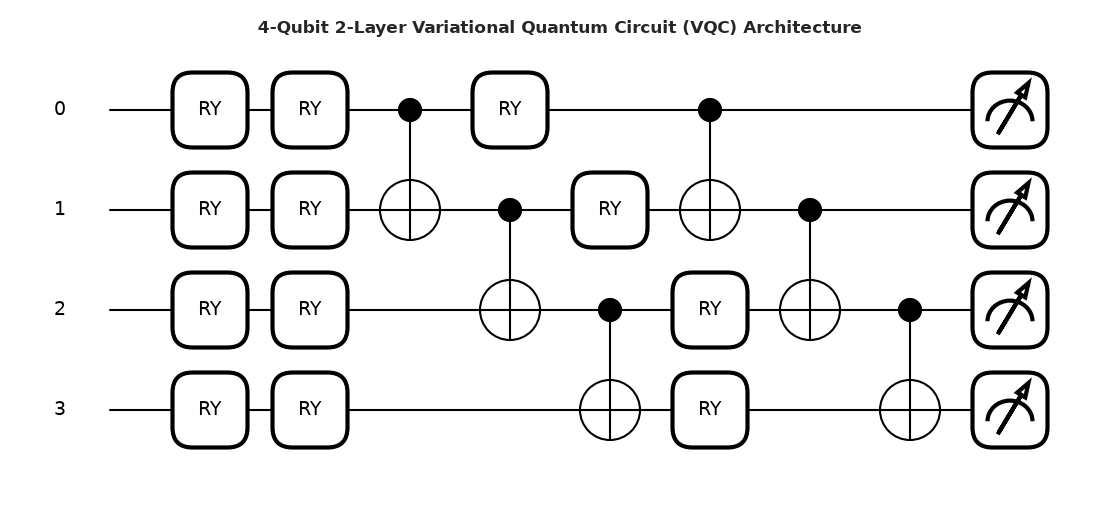

Quantum Circuit Architecture:
0: ──RY(3.14)──RY(0.00)─╭●──RY(0.00)───────────╭●──────────────┤  <Z>
1: ──RY(0.00)──RY(0.00)─╰X─╭●─────────RY(0.00)─╰X────────╭●────┤  <Z>
2: ──RY(1.51)──RY(0.00)────╰X────────╭●─────────RY(0.00)─╰X─╭●─┤  <Z>
3: ──RY(0.00)──RY(0.00)──────────────╰X─────────RY(0.00)────╰X─┤  <Z>


In [3]:
# ==============================================================================
# 2. PENNYLANE 4-QUBIT 2-LAYER VQC QUANTUM NODE
# ==============================================================================

n_qubits = 4
n_layers = 2

# Instantiate noiseless statevector simulator
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def vqc_circuit(x, weights):
    # 1. Data Encoding: RY(x_i * pi) on each wire
    for i in range(n_qubits):
        qml.RY(x[..., i] * pnp.pi, wires=i)
        
    # 2. VQC Layer 1: RY(theta_1, theta_3, theta_5, theta_7) + Linear CNOT Entanglement
    for i in range(n_qubits):
        qml.RY(weights[0, i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
        
    # 3. VQC Layer 2: RY(theta_2, theta_4, theta_6, theta_8) + Linear CNOT Entanglement
    for i in range(n_qubits):
        qml.RY(weights[1, i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
        
    # 4. Measurement: Pauli-Z expectation across all 4 qubits
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

def forward_probabilities(x, weights, bias):
    """
    Computes binary classification probability p(y=1|x):
    sigma(<Z> + bias) where <Z> is the mean Pauli-Z expectation across all 4 qubits.
    """
    res = vqc_circuit(x, weights)
    stacked = pnp.stack(res, axis=-1)
    z_mean = pnp.mean(stacked, axis=-1)
    logits = z_mean + bias
    return 1.0 / (1.0 + pnp.exp(-logits))

def loss_fn(weights, bias, x, y):
    probs = forward_probabilities(x, weights, bias)
    probs_clipped = pnp.clip(probs, 1e-7, 1.0 - 1e-7)
    return -pnp.mean(y * pnp.log(probs_clipped) + (1.0 - y) * pnp.log(1.0 - probs_clipped))

# Draw and display quantum circuit schematic
sample_x = pnp.array(X_train[0], requires_grad=False)
sample_w = pnp.zeros((n_layers, n_qubits), requires_grad=False)

fig, ax = qml.draw_mpl(vqc_circuit)(sample_x, sample_w)
fig.suptitle("4-Qubit 2-Layer Variational Quantum Circuit (VQC) Architecture", fontsize=12, fontweight="bold")
plt.savefig(FIGURES_DIR / "vqc_circuit_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

print("Quantum Circuit Architecture:")
print(qml.draw(vqc_circuit)(sample_x, sample_w))


---
## 3. Mini-Batch Training Loop with Validation Checkpointing

We train the variational parameters using:
* **Optimizer**: PennyLane `AdamOptimizer(stepsize=0.03)`
* **Loss Function**: Binary Cross-Entropy (BCE)
* **Batch Size**: 64 samples per mini-batch
* **Epochs**: 20 epochs
* **Model Checkpointing**: The parameters $(\mathbf{W}^*, b^*)$ that achieve the lowest validation loss are checkpointed.


In [4]:
# ==============================================================================
# 3. VQC TRAINING EXECUTION
# ==============================================================================

# Initialize trainable parameters: 8 quantum rotation angles + 1 classical bias
weights = pnp.random.uniform(0.0, 2.0 * pnp.pi, (n_layers, n_qubits), requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)

total_params = weights.size + 1
print(f"Total Trainable Parameters: {total_params} ({weights.size} quantum rotation angles [theta_1..theta_8] + 1 classical bias)")

optimizer = qml.AdamOptimizer(stepsize=0.03)
batch_size = 64
n_epochs = 20

best_val_loss = float("inf")
best_weights = weights.copy()
best_bias = bias.copy()
best_epoch = 0

history = []
X_val_pnp = pnp.array(X_val, requires_grad=False)
y_val_pnp = pnp.array(y_val, requires_grad=False)

print("Starting Noiseless VQC Training Protocol...")
print("--------------------------------------------------------------------------------")

start_time = time.time()

for epoch in range(1, n_epochs + 1):
    epoch_start = time.time()
    permutation = np.random.permutation(len(X_train))
    X_shuffled = X_train[permutation]
    y_shuffled = y_train[permutation]
    
    batch_losses = []
    for i in range(0, len(X_train), batch_size):
        xb = pnp.array(X_shuffled[i:i + batch_size], requires_grad=False)
        yb = pnp.array(y_shuffled[i:i + batch_size], requires_grad=False)
        (weights, bias), batch_l = optimizer.step_and_cost(
            lambda w, b: loss_fn(w, b, xb, yb),
            weights,
            bias
        )
        batch_losses.append(float(batch_l))
        
    train_loss = float(np.mean(batch_losses))
    val_loss = float(loss_fn(weights, bias, X_val_pnp, y_val_pnp))
    
    val_probs = np.array(forward_probabilities(X_val_pnp, weights, bias))
    val_preds = (val_probs >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, val_preds)
    val_bacc = balanced_accuracy_score(y_val, val_preds)
    val_auc = roc_auc_score(y_val, val_probs)
    
    is_best = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = weights.copy()
        best_bias = bias.copy()
        best_epoch = epoch
        is_best = " [*Best Model]"
        
    epoch_time = time.time() - epoch_start
    history.append({
        "Epoch": epoch,
        "Train Loss": round(train_loss, 4),
        "Val Loss": round(val_loss, 4),
        "Val Accuracy": round(val_acc, 4),
        "Val Balanced Acc": round(val_bacc, 4),
        "Val ROC-AUC": round(val_auc, 4),
        "Time (s)": round(epoch_time, 2)
    })
    
    print(f"Epoch {epoch:02d}/{n_epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val Balanced Acc: {val_bacc:.4f} | Val AUC: {val_auc:.4f} ({epoch_time:.2f}s){is_best}")

total_time = time.time() - start_time
print("--------------------------------------------------------------------------------")
print(f"Training completed in {total_time:.2f}s. Best Checkpoint: Epoch {best_epoch:02d} (Val Loss: {best_val_loss:.4f})")

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_MODEL_DIR / "training_history.csv", index=False)
np.save(OUTPUT_MODEL_DIR / "vqc_weights.npy", np.array(best_weights))
np.save(OUTPUT_MODEL_DIR / "vqc_bias.npy", np.array(best_bias))


Total Trainable Parameters: 9 (8 quantum rotation angles [theta_1..theta_8] + 1 classical bias)
Starting Noiseless VQC Training Protocol...
--------------------------------------------------------------------------------


Epoch 01/20 | Train Loss: 0.6952 | Val Loss: 0.6980 | Val Balanced Acc: 0.4954 | Val AUC: 0.5028 (0.26s) [*Best Model]


Epoch 02/20 | Train Loss: 0.6927 | Val Loss: 0.6969 | Val Balanced Acc: 0.5057 | Val AUC: 0.4999 (0.25s) [*Best Model]


Epoch 03/20 | Train Loss: 0.6910 | Val Loss: 0.6968 | Val Balanced Acc: 0.4937 | Val AUC: 0.4895 (0.33s) [*Best Model]


Epoch 04/20 | Train Loss: 0.6907 | Val Loss: 0.6968 | Val Balanced Acc: 0.4768 | Val AUC: 0.4894 (0.25s)


...

Epoch 16/20 | Train Loss: 0.6908 | Val Loss: 0.6971 | Val Balanced Acc: 0.4918 | Val AUC: 0.4882 (0.34s)


Epoch 17/20 | Train Loss: 0.6909 | Val Loss: 0.6963 | Val Balanced Acc: 0.4865 | Val AUC: 0.4932 (0.24s)


Epoch 18/20 | Train Loss: 0.6912 | Val Loss: 0.6973 | Val Balanced Acc: 0.4874 | Val AUC: 0.4861 (0.24s)


Epoch 19/20 | Train Loss: 0.6913 | Val Loss: 0.6976 | Val Balanced Acc: 0.4960 | Val AUC: 0.4870 (0.28s)


Epoch 20/20 | Train Loss: 0.6906 | Val Loss: 0.6965 | Val Balanced Acc: 0.4956 | Val AUC: 0.4935 (0.41s)
--------------------------------------------------------------------------------
Training completed in 5.85s. Best Checkpoint: Epoch 07 (Val Loss: 0.6950)


---
## 4. Training Progression Visualizations

We plot the training loss curve and the validation balanced accuracy progression across the 20 epochs.


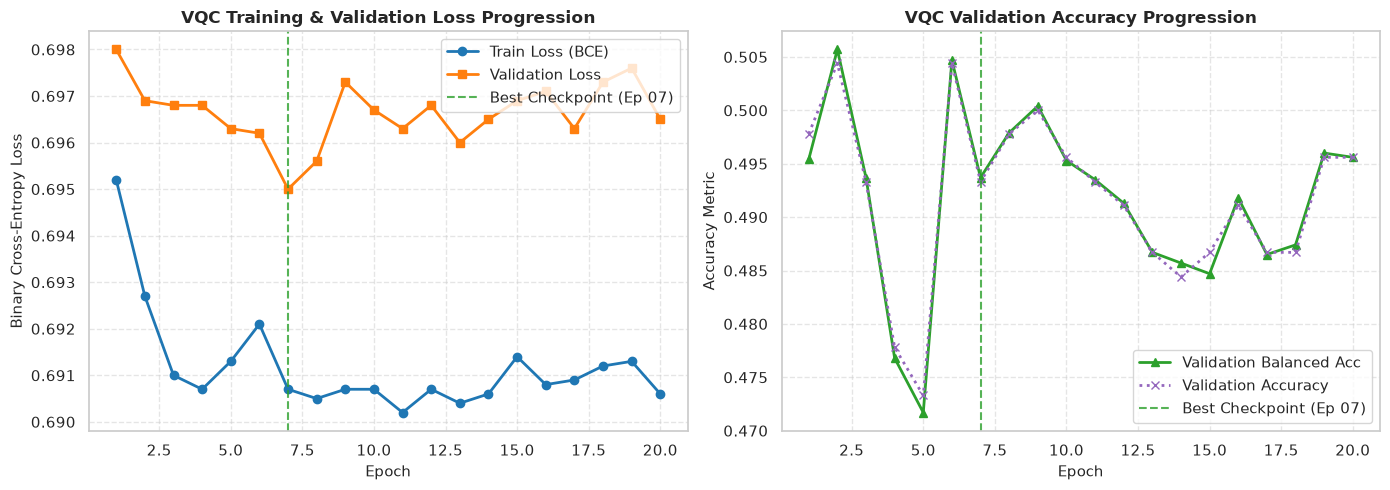

In [5]:
# ==============================================================================
# 4. PLOT TRAINING & VALIDATION PROGRESSION
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curves
axes[0].plot(history_df["Epoch"], history_df["Train Loss"], marker="o", linewidth=2, label="Train Loss (BCE)", color="#1f77b4")
axes[0].plot(history_df["Epoch"], history_df["Val Loss"], marker="s", linewidth=2, label="Validation Loss", color="#ff7f0e")
axes[0].axvline(best_epoch, color="#2ca02c", linestyle="--", alpha=0.8, label=f"Best Checkpoint (Ep {best_epoch:02d})")
axes[0].set_title("VQC Training & Validation Loss Progression", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Binary Cross-Entropy Loss", fontsize=11)
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Balanced Accuracy Curves
axes[1].plot(history_df["Epoch"], history_df["Val Balanced Acc"], marker="^", linewidth=2, label="Validation Balanced Acc", color="#2ca02c")
axes[1].plot(history_df["Epoch"], history_df["Val Accuracy"], marker="x", linewidth=2, linestyle=":", label="Validation Accuracy", color="#9467bd")
axes[1].axvline(best_epoch, color="#2ca02c", linestyle="--", alpha=0.8, label=f"Best Checkpoint (Ep {best_epoch:02d})")
axes[1].set_title("VQC Validation Accuracy Progression", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Accuracy Metric", fontsize=11)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "vqc_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 5. Final Out-of-Sample Evaluation on Holdout Test Set

We evaluate the optimal checkpointed VQC model against the unseen holdout test set (450 samples).


 FINAL TEST SET EVALUATION REPORT (450 SAMPLES)
Accuracy:                 52.67%
Balanced Accuracy:        52.69%
Sensitivity (Recall):     49.78%
Specificity:              55.61%
Precision:                53.30%
F1-Score:                 51.48%
ROC-AUC:                  0.5147
--------------------------------------------------------------------------------
Confusion Matrix: TN=124, FP=99, FN=114, TP=113


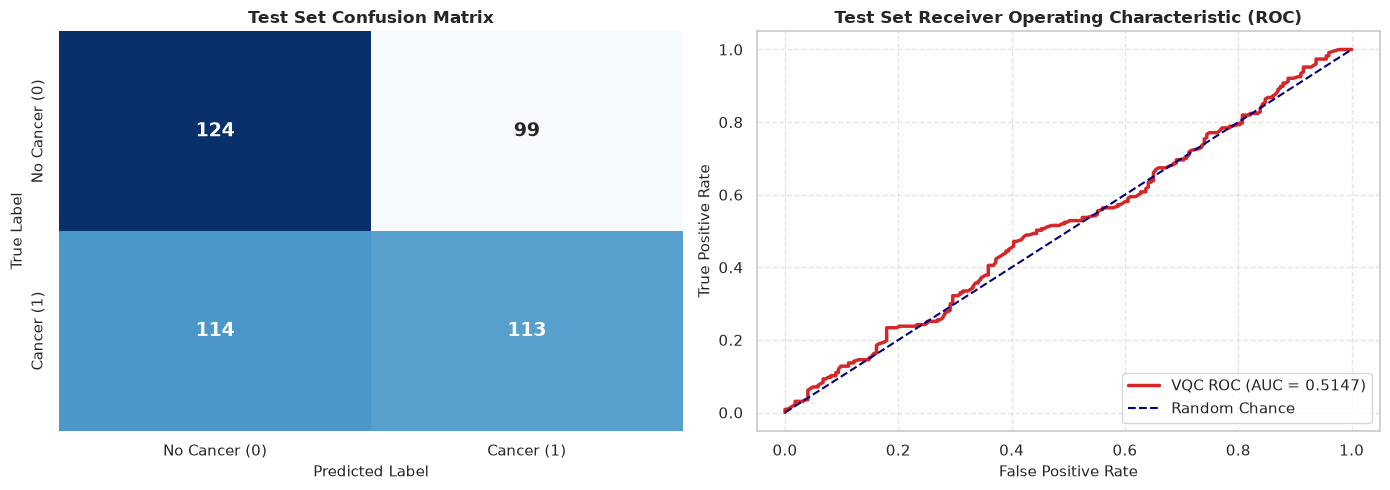

In [6]:
# ==============================================================================
# 5. HOLDOUT TEST SET EVALUATION
# ==============================================================================

X_test_pnp = pnp.array(X_test, requires_grad=False)
test_probs = np.array(forward_probabilities(X_test_pnp, best_weights, best_bias))
test_preds = (test_probs >= 0.5).astype(int)

test_acc = float(accuracy_score(y_test, test_preds))
test_bacc = float(balanced_accuracy_score(y_test, test_preds))
test_sens = float(recall_score(y_test, test_preds, pos_label=1))
test_spec = float(recall_score(y_test, test_preds, pos_label=0))
test_prec = float(precision_score(y_test, test_preds, pos_label=1, zero_division=0))
test_f1 = float(f1_score(y_test, test_preds, pos_label=1, zero_division=0))
test_auc = float(roc_auc_score(y_test, test_probs))
cm = confusion_matrix(y_test, test_preds)

print("================================================================================")
print(" FINAL TEST SET EVALUATION REPORT (450 SAMPLES)")
print("================================================================================")
print(f"Accuracy:                 {test_acc * 100:.2f}%")
print(f"Balanced Accuracy:        {test_bacc * 100:.2f}%")
print(f"Sensitivity (Recall):     {test_sens * 100:.2f}%")
print(f"Specificity:              {test_spec * 100:.2f}%")
print(f"Precision:                {test_prec * 100:.2f}%")
print(f"F1-Score:                 {test_f1 * 100:.2f}%")
print(f"ROC-AUC:                  {test_auc:.4f}")
print("--------------------------------------------------------------------------------")
print(f"Confusion Matrix: TN={cm[0, 0]}, FP={cm[0, 1]}, FN={cm[1, 0]}, TP={cm[1, 1]}")
print("================================================================================")

# Plot Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["No Cancer (0)", "Cancer (1)"],
            yticklabels=["No Cancer (0)", "Cancer (1)"],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("Test Set Confusion Matrix", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, color="#d62728", lw=2.5, label=f"VQC ROC (AUC = {test_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random Chance")
axes[1].set_title("Test Set Receiver Operating Characteristic (ROC)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate", fontsize=11)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "vqc_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 6. Model Artifacts & Test Metrics Export


In [7]:
# ==============================================================================
# 6. EXPORT METRICS & FINAL SIGN-OFF
# ==============================================================================

test_summary = {
    "model": "4-Qubit 2-Layer Variational Quantum Classifier (VQC)",
    "framework": f"PennyLane {qml.__version__}",
    "device": "default.qubit (Noiseless Statevector Simulator)",
    "architecture": "4-Qubit 2-Layer VQC with Linear CNOT Entanglement",
    "observable": "Pauli-Z Expectation (<Z> pooled over 4 qubits)",
    "features": selected_features,
    "metrics": {
        "Accuracy": round(test_acc, 4),
        "Balanced Accuracy": round(test_bacc, 4),
        "Sensitivity": round(test_sens, 4),
        "Specificity": round(test_spec, 4),
        "Precision": round(test_prec, 4),
        "F1-score": round(test_f1, 4),
        "ROC-AUC": round(test_auc, 4)
    }
}

with open(OUTPUT_MODEL_DIR / "test_metrics.json", "w") as f:
    json.dump(test_summary, f, indent=4)

print("Saved: test_metrics.json")
print("Saved: vqc_weights.npy & vqc_bias.npy")
print("Saved: training_history.csv")
print("Saved: All visualizations in figures/")
print("\n================================================================================")
print("             4-QUBIT 2-LAYER VQC TRAINING COMPLETE")
print("================================================================================")


Saved: test_metrics.json
Saved: vqc_weights.npy & vqc_bias.npy
Saved: training_history.csv
Saved: All visualizations in figures/

             4-QUBIT 2-LAYER VQC TRAINING COMPLETE
